# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [2]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=99a1770cfa42dfe5429b0e8515d36eccfe83942911d5ab602c0cd915a32c002f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [4]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답:

LIME의 핵심 동작 과정은 다음과 같은 5단계로 이루어진다.

**1) 샘플 생성 (Perturbation):** 설명하고자 하는 타겟 데이터 포인트 주변에서 원본 특징을 무작위로 껐다 켜서 수많은 '가짜 샘플(perturbed instances)'을 생성한다. 각 가짜 샘플은 어떤 특징이 포함되어 있는지를 이진 벡터(z')로 기록한다.

**2) 가중치 부여 (Distance Kernel):** 생성된 가짜 샘플들이 원본 데이터와 얼마나 가까운지 거리를 계산하여 가중치 π_x(z)를 부여한다. 원본에 가까운 샘플일수록 높은 가중치를 받으며, 가중치 함수는 π_x(z) = exp(-D(x,z)² / σ²) 형태의 커널을 사용한다.

**3) 예측값 도출 (Score Function):** 가짜 샘플들을 블랙박스 모델 f에 넣어서 예측 점수(확률)를 얻는다. 이것이 surrogate model이 학습할 타겟값이 된다.

**4) 핵심 특징 선택 (Lasso):** 불필요한 노이즈를 제거하고 예측에 큰 영향을 주는 Top K개의 특징만 남기기 위해 Lasso 정규화를 사용하여 핵심 특징을 선택한다.

**5) 선형 모델 학습 (Explanation):** 선택된 핵심 특징과 가중치를 사용하여 해석 가능한 선형 모델 g를 학습시킨다. 이 선형 모델의 각 계수가 해당 특징의 기여도(설명)가 된다. 최종적으로 ξ(x) = argmin L(f, g, π_x) + Ω(g)를 최소화하는 모델 g를 찾는 것이 LIME의 목표이다.

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답:

LIME에서 surrogate model(대리 모델)은 복잡한 블랙박스 모델의 **국소적(local) 행동을 근사(approximation)**하기 위해 사용되는 해석 가능한 단순한 모델이다.

구체적으로, surrogate model의 역할은 다음과 같다:

1. **블랙박스 모델 모방:** 설명하고자 하는 특정 데이터 포인트(x) 주변에서 블랙박스 모델 f의 예측 행동을 단순한 선형 모델 g로 모방한다. 즉, f(z) ≈ g(z')이 되도록 학습한다.

2. **해석 가능성 제공:** surrogate model로는 선형 회귀(Linear Regression)와 같은 해석이 쉬운 모델을 사용한다. 이를 통해 각 특징이 예측에 미치는 영향(기여도)을 선형 계수로 직관적으로 파악할 수 있다.

3. **국소적 충실도(Local Fidelity) 보장:** surrogate model은 전체 데이터에 대해 블랙박스 모델을 완벽히 모사할 필요 없이, 관심 데이터 포인트 주변의 국소적 영역에서만 충실하게 근사하면 된다. 이를 위해 거리 기반 가중치 π_x(z)를 사용하여 타겟 데이터에 가까운 샘플에 더 높은 중요도를 부여한다.

결과적으로 surrogate model은 "이 데이터 포인트에 대해 블랙박스 모델이 왜 이런 예측을 했는가?"에 대한 해석 가능한 설명을 제공하는 핵심 역할을 한다.

---

#2. SHAP

In [6]:
!pip install shap

### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


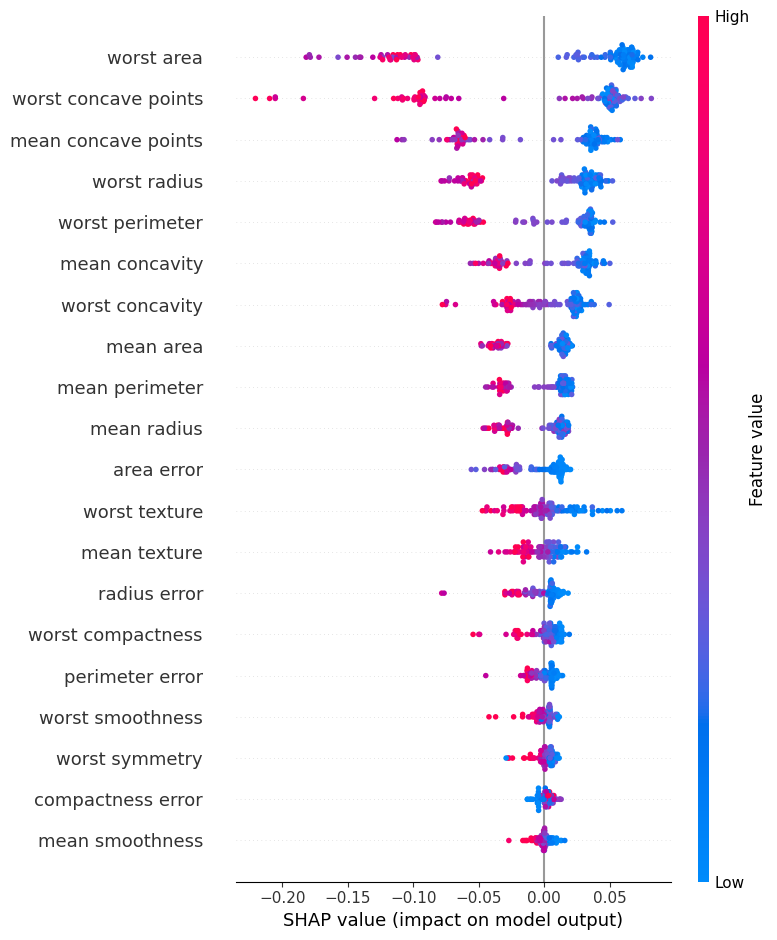

In [7]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답:

SHAP Value는 각 특성이 모델의 기대값(base value, E[f(z)])으로부터 해당 데이터 포인트의 실제 예측값 f(x)까지 얼마나 기여했는지를 나타내는 값이다.

- **SHAP Value가 양수(+)인 특성:** 해당 특성이 모델의 예측값을 **증가시키는 방향**으로 기여했음을 의미한다. 예를 들어 유방암 분류에서 클래스 1(benign)에 대한 SHAP Value가 양수이면, 해당 특성이 양성(benign)으로 예측할 확률을 높이는 데 긍정적으로 기여한 것이다.

- **SHAP Value가 음수(-)인 특성:** 해당 특성이 모델의 예측값을 **감소시키는 방향**으로 기여했음을 의미한다. 같은 예시에서 SHAP Value가 음수이면, 해당 특성이 악성(malignant) 쪽으로 예측을 끌어당기는 역할을 한 것이다.

SHAP의 핵심 성질인 **Local Accuracy**에 의해, 모든 특성의 SHAP Value 합 + base value = 해당 데이터의 최종 예측값이 되므로, 양수/음수 SHAP Value의 합산을 통해 최종 예측이 어떻게 구성되었는지 완벽하게 분해하여 설명할 수 있다.

Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답:

**1) 계산 방식의 차이:**
- **Gini/Entropy 기반 Feature Importance:** 트리의 각 노드에서 해당 특성이 분기에 사용될 때 불순도(Gini index 또는 Entropy)가 얼마나 감소했는지를 전체 트리에 걸쳐 합산한 값이다. 즉, 특성이 트리 분기에 얼마나 자주, 얼마나 효과적으로 사용되었는지를 측정한다.
- **SHAP Feature Importance:** 게임이론의 Shapley Value를 기반으로, 모든 가능한 특성 조합에서 해당 특성의 유무에 따른 예측값의 평균적인 한계 기여도(Marginal Contribution)를 계산한다.

**2) 설명 범위의 차이:**
- **Gini/Entropy:** 모델 전체에 대한 **Global** importance만 제공한다. 개별 데이터 포인트에 대해 "왜 이렇게 예측했는가?"를 설명할 수 없다.
- **SHAP:** **Local + Global** 모두 지원한다. 개별 데이터 포인트별로 각 특성의 기여도를 계산(Local)할 수 있고, 이를 합산하면 전체 모델에 대한 Global 설명도 가능하다.

**3) 수학적 완결성의 차이:**
- **Gini/Entropy:** 특성 간 상호작용이나 상관관계를 제대로 반영하지 못하며, 높은 cardinality를 가진 특성에 편향(bias)될 수 있다.
- **SHAP:** 3대 공리(Local Accuracy/가법성, Missingness/결측성, Consistency/일관성)를 수학적으로 완벽하게 충족하는 유일한 방법이므로, 더 공정하고 이론적으로 견고한 기여도 분배를 보장한다.

**4) 방향성 정보:**
- **Gini/Entropy:** 특성의 중요도 크기만 알 수 있고, 특성값이 예측을 어느 방향으로 밀었는지 알 수 없다.
- **SHAP:** 양수/음수 값을 통해 해당 특성이 예측을 어느 방향으로 기여했는지 방향성 정보까지 제공한다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 66.9MB/s]


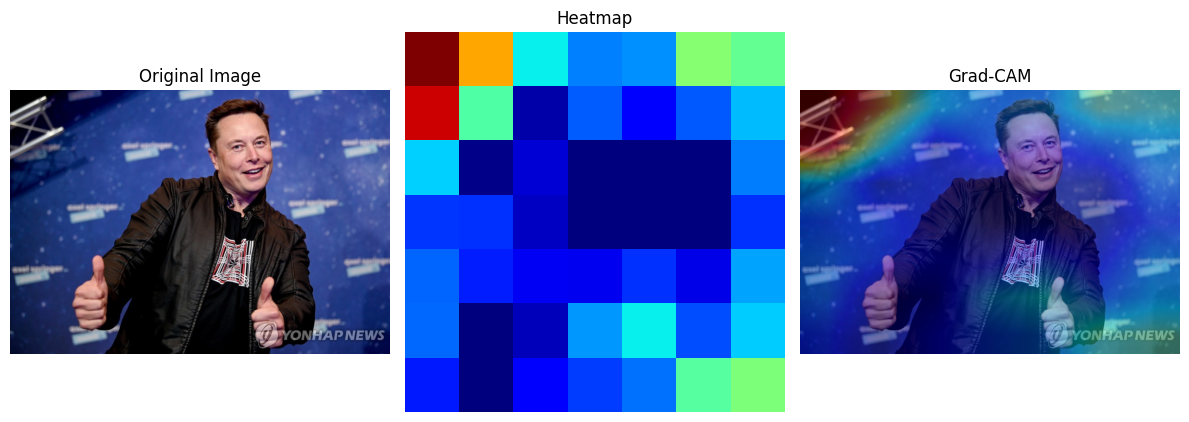

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답:
Grad-CAM이 마지막 컨볼루션 층의 정보를 사용하는 이유는 크게 두 가지이다.

**1) 의미론적 정보(Semantic Information)와 공간 정보(Spatial Information)의 최적 균형:**
CNN에서 얕은 층(초기 층)은 엣지, 텍스처 같은 저수준 특징을 담고 있고, 깊은 층(마지막 층)으로 갈수록 객체의 부분이나 전체적인 형태 등 고수준의 의미론적 특징을 담게 된다. 마지막 컨볼루션 층은 가장 풍부한 의미론적 정보를 담고 있으면서도, Fully Connected 층과 달리 아직 공간적 구조(가로×세로)를 유지하고 있다. 따라서 "어떤 영역이 중요한지"를 공간적으로 표현할 수 있다.

**2) CAM의 구조적 한계 극복:**
기존 CAM은 반드시 모델의 마지막 부분에 FC 레이어를 제거하고 GAP(Global Average Pooling) 레이어를 넣는 구조 변경이 필요했다. 반면 Grad-CAM은 마지막 컨볼루션 층에 흐르는 그래디언트(역전파)를 활용하여 각 feature map의 가중치(α_k^c)를 계산하므로, 모델 구조를 변경하지 않고도 임의의 CNN 모델에 적용할 수 있다. 그래디언트를 Global Average Pooling하여 가중치를 구하는 것은 수학적으로 CAM의 가중치와 동일한 역할을 한다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답:

Grad-CAM 히트맵에서 붉게 표시되는 영역(High Activation)은 모델이 특정 클래스로 분류하는 데 **가장 크게 기여한 이미지 영역**을 나타낸다.

구체적으로 설명하면, Grad-CAM의 히트맵 값은 L^c_Grad-CAM = ReLU(Σ_k α_k^c · A^k)로 계산된다. 여기서 α_k^c는 타겟 클래스 c에 대한 출력값 y^c를 feature map A^k의 각 원소로 편미분한 그래디언트를 Global Average Pooling한 값이다. 즉, α_k^c = (1/Z) Σ_i Σ_j (∂y^c / ∂A^k_{i,j}) 이다.

따라서 붉은 영역이 의미하는 바는:

1. **해당 영역의 feature map 활성화(A^k)와 그래디언트(∂y^c/∂A^k) 모두 높은 곳**이다. 이는 그 영역이 타겟 클래스의 예측 확률을 높이는 데 가장 중요한 시각적 증거를 담고 있다는 뜻이다.

2. **ReLU를 적용**하기 때문에 양의 영향(positive influence)만 시각화한다. 즉, 해당 클래스의 예측 확률을 증가시키는 방향으로 기여하는 영역만 표시된다.

3. 반대로 파란색(낮은 값) 영역은 모델의 해당 클래스 예측에 상대적으로 기여가 적은 부분을 의미한다.

예를 들어, 개 이미지를 분류할 때 붉은 영역이 개의 얼굴 부분에 집중되어 있다면, 모델이 개의 얼굴 특징을 주요 근거로 해당 클래스를 예측했다고 해석할 수 있다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답:

이 실습에서 사용한 이미지는 연합뉴스의 동물(판다 등) 사진으로, VGG16 모델이 ImageNet 클래스 중 하나로 예측한 결과에 대한 Grad-CAM 히트맵을 생성한 것이다.

Grad-CAM 히트맵이 항상 이미지의 중요한 객체를 정확히 담고 있다고 보장할 수는 없으며, 몇 가지 한계가 존재한다:

**1) 해상도의 한계:** Grad-CAM은 마지막 컨볼루션 층의 feature map 크기에 기반하여 히트맵을 생성한다. VGG16의 경우 마지막 conv층의 feature map은 14×14로, 원본 이미지(224×224)보다 훨씬 낮은 해상도를 가진다. 이를 원본 크기로 업샘플링하기 때문에 히트맵이 뭉개지고, 객체의 세밀한 윤곽보다는 대략적인 위치만 표현할 수 있다.

**2) 모델의 판단 기준 문제:** 모델이 반드시 인간이 생각하는 "핵심 객체"를 보고 예측하는 것은 아니다. 모델이 배경이나 맥락 정보(예: 특정 환경, 질감)에 의존하여 예측했을 수 있으며, 이 경우 히트맵이 객체가 아닌 배경에 집중될 수 있다. 이는 모델의 spurious correlation(가짜 상관관계) 문제를 드러내는 것이기도 하다.

**3) 단일 클래스 기반 시각화:** Grad-CAM은 예측된 하나의 클래스에 대한 히트맵만 보여주므로, 이미지에 여러 객체가 있을 경우 예측 클래스와 관련된 객체만 하이라이트하고 나머지는 무시할 수 있다.

따라서 Grad-CAM은 모델이 "실제로 어디를 봤는지"를 시각화하는 도구이지, 반드시 인간이 생각하는 핵심 객체와 일치하는 것은 아니다. 오히려 히트맵이 엉뚱한 곳을 가리킬 때, 모델이 잘못된 근거로 예측하고 있다는 디버깅 정보를 제공할 수 있다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [9]:
# 이미지 로드 및 전처리
url = 'https://blog.kakaocdn.net/dna/cyD9pn/btsOxFfpiiW/AAAAAAAAAAAAAAAAAAAAAFGiOvHL_qlCUiUiUIg1JagJFnkaarNn8GiOBCO__hEp/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1774969199&allow_ip=&allow_referer=&signature=yWd4YCmf%2B1q9tAkMCHkW0O6PyJQ%3D'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7cd57b50c180>

In [10]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [11]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [ ]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

In [ ]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [ ]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

In [ ]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



In [ ]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답:

기존의 단일 레이어 Attention Score 대신 Attention Rollout 방법을 사용하는 이유는 다음과 같다.

**1) 단일 레이어 Attention의 한계:**
Transformer(ViT 등)는 여러 개의 레이어가 쌓여 있으며, 각 레이어마다 attention 행렬이 존재한다. 단일 레이어의 attention score만 보면, 그 레이어에서 토큰 간의 직접적인 관계만 볼 수 있을 뿐, 여러 레이어를 거치면서 정보가 어떻게 흘러갔는지(information flow)를 파악할 수 없다. 예를 들어, 레이어 1에서 토큰 A가 토큰 B에 attention하고, 레이어 2에서 토큰 B가 토큰 C에 attention했다면, 실질적으로 토큰 A의 정보가 토큰 C까지 흘러간 것인데, 단일 레이어 attention만으로는 이러한 간접적 경로를 포착할 수 없다.

**2) Attention Rollout의 해결 방법:**
Attention Rollout은 모든 레이어의 attention 행렬을 순차적으로 곱해나감으로써(행렬 곱), 입력 토큰에서 최종 출력까지의 **전체적인 attention 흐름**을 추적한다. 또한 각 레이어에서 residual connection을 반영하기 위해 항등 행렬(Identity Matrix)을 더해주고, row normalization을 수행하여 확률 분포를 유지한다.

**3) 멀티헤드 어텐션 통합:**
각 레이어에는 여러 개의 attention head가 있는데, Attention Rollout은 이들을 평균(mean)하여 하나로 통합한 후 곱셈을 진행한다. 이를 통해 여러 head의 다양한 관점을 종합적으로 반영할 수 있다.

결과적으로, Attention Rollout은 CLS 토큰이 각 패치 토큰으로부터 얼마나 정보를 받았는지를 전체 네트워크 깊이에 걸쳐 종합적으로 보여주므로, 단일 레이어 attention보다 훨씬 더 정확하고 의미 있는 해석을 제공할 수 있다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답:
Attention Score가 높은 토큰들을 활용하여 다양한 방법론을 만들 수 있다. 몇 가지 예시를 제시한다.

**1) Fine-Grained Visual Recognition (세밀한 시각 인식):**
ViT에서 Attention Score가 높은 patch token들을 따로 모아서 discriminative features로 활용할 수 있다. 예를 들어, 새의 종류를 분류할 때 attention이 높은 패치(부리, 날개 무늬 등)만 크롭(crop)하여 별도의 분류기에 입력하면, 세밀한 차이를 더 잘 구별할 수 있다. TransFG, FFVT 같은 논문에서 이런 접근법을 사용한다.

**2) Token Pruning / Efficient Inference (토큰 가지치기):**
Attention Score가 낮은 토큰들은 모델의 판단에 기여가 적으므로, 이를 중간 레이어에서 제거(pruning)하여 연산량을 줄이는 효율적인 추론 방법을 만들 수 있다. DynamicViT, EViT 등의 논문에서 이 방법을 활용하여 ViT의 추론 속도를 크게 향상시켰다.

**3) Weakly-Supervised Object Localization (약지도 객체 검출):**
Attention Score가 높은 patch들의 위치 정보를 활용하면, bounding box annotation 없이도 이미지 내 객체의 대략적인 위치를 파악할 수 있다. 클래스 레이블만으로 학습된 ViT의 attention map을 객체 위치 추정에 활용하는 것이다.

**4) NLP에서의 Key Sentence/Token Extraction:**
텍스트 모델에서 attention score가 높은 word token들을 추출하여 핵심 키워드나 중요 문장을 선별하는 데 활용할 수 있다. 이는 문서 요약(Summarization)이나 질의응답(QA)에서 근거 문장(supporting evidence)을 찾는 데 응용될 수 있다.